**Objective:**

The objective of this linear regression model is to analyze and predict the Air Quality Index (AQI) based on independent variables such as patient age, recovery days, temperature (°C), humidity (%), rodent presence index, and quarantine days. The model aims to identify the relationship between these factors and air quality, helping to understand how changes air quality and enabling accurate prediction of air quality levels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')
# Display first  rows
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [ ]:
df.shape

(2000, 19)

In [ ]:
df.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

In [ ]:
df.dtypes

,0
case_id,object
country,object
region,object
report_date,object
virus_strain,object
transmission_type,object
exposure_source,object
patient_age,int64
gender,object
symptoms,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-null   object 
 7   patient_age            2000 non-null   int64  
 8   gender                 2000 non-null   object 
 9   symptoms               2000 non-null   object 
 10  hospitalization        2000 non-null   object 
 11  fatality               2000 non-null   object 
 12  recovery_days          1845 non-null   float64
 13  temperature_celsius    2000 non-null   float64
 14  humidity_percent       2000 non-null   float64
 15  rode

In [ ]:
df.duplicated().any()

np.False_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index


In [ ]:
data1 = df.drop_duplicates()

In [ ]:
data1.shape

(2000, 19)

In [ ]:
#check missing values
data1.isnull().any()

,0
case_id,False
country,False
region,False
report_date,False
virus_strain,False
transmission_type,False
exposure_source,False
patient_age,False
gender,False
symptoms,False


In [ ]:
data1.isnull().sum()

,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


In [ ]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and gind out null value percentage
df['% null_records'] = (df['null_records']/2000)*100
df

,column,null_records,% null_records
0,case_id,0,0.00
1,country,0,0.00
2,region,0,0.00
3,report_date,0,0.00
4,virus_strain,0,0.00
5,transmission_type,0,0.00
6,exposure_source,0,0.00
7,patient_age,0,0.00
8,gender,0,0.00
9,symptoms,0,0.00


In [ ]:
recovery_days_mean = data1['recovery_days'].mean()
recovery_days_mean
data1['recovery_days'] = data1['recovery_days'].fillna(recovery_days_mean)

In [ ]:
data1.isnull().sum()

,0
case_id,0
country,0
region,0
report_date,0
virus_strain,0
transmission_type,0
exposure_source,0
patient_age,0
gender,0
symptoms,0


In [ ]:
data1 = data1.dropna()

In [ ]:
data1.shape

(2000, 19)

In [ ]:
# List of Categorical and Numeric Columns

Numerical_columns = data1.select_dtypes(include="number").columns.to_list()
print(Numerical_columns)

['patient_age', 'recovery_days', 'temperature_celsius', 'humidity_percent', 'rodent_presence_index', 'quarantine_days', 'population_density', 'air_quality_index']


In [ ]:
Categorical_columns = data1.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

['case_id', 'country', 'region', 'report_date', 'virus_strain', 'transmission_type', 'exposure_source', 'gender', 'symptoms', 'hospitalization', 'fatality']


In [ ]:

# Statistical Measure of Numeric Columns
data1.describe()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,45.196000,26.293225,24.174850,64.623400,5.494500,10.551500,4968.62350,159.701000
std,19.115001,10.827548,5.981896,17.466002,2.868115,6.369037,2961.87065,81.034152
min,12.000000,7.000000,4.600000,35.000000,1.000000,0.000000,54.00000,20.000000
25%,29.000000,17.000000,20.200000,49.500000,3.000000,5.000000,2341.25000,89.000000
50%,46.000000,26.293225,24.200000,64.550000,5.000000,11.000000,4952.50000,162.000000
75%,62.000000,35.000000,28.000000,79.825000,8.000000,16.000000,7648.75000,231.250000
max,78.000000,45.000000,47.600000,95.000000,10.000000,21.000000,9999.00000,300.000000


In [ ]:
# Categorical column extraction
data1.describe(include="object")

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,gender,symptoms,hospitalization,fatality
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,10,1850,490,5,2,6,2,5,2,2
top,HV2026_01984,Bolivia,New Matthew,18-01-2026,Sin Nombre,Human-to-Human,Cruise Exposure,Male,"Fever, Muscle Pain, Fatigue",Yes,No
freq,1,215,4,12,431,1001,354,1005,405,1007,1845


In [ ]:
data1


,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,HV2026_01996,Bolivia,South Lauren,12-01-2026,Andes,Rodent-to-Human,Home Infestation,43,Female,"Shortness of Breath, Fever",No,No,30.0,25.9,71.6,2,2,9022,72
1996,HV2026_01997,Brazil,New Patriciaview,16-12-2025,Puumala,Human-to-Human,Rodent Exposure,52,Female,"Shortness of Breath, Fever",Yes,No,35.0,17.3,50.7,8,14,7014,67
1997,HV2026_01998,Mexico,Cowanbury,19-09-2025,Dobrava,Human-to-Human,Warehouse Exposure,64,Female,"Headache, Vomiting, Fever",No,No,24.0,23.8,60.1,3,19,309,210
1998,HV2026_01999,Paraguay,Wendyborough,31-12-2025,Seoul,Rodent-to-Human,Home Infestation,29,Male,"Shortness of Breath, Fever",No,No,45.0,26.1,52.3,3,7,3843,21


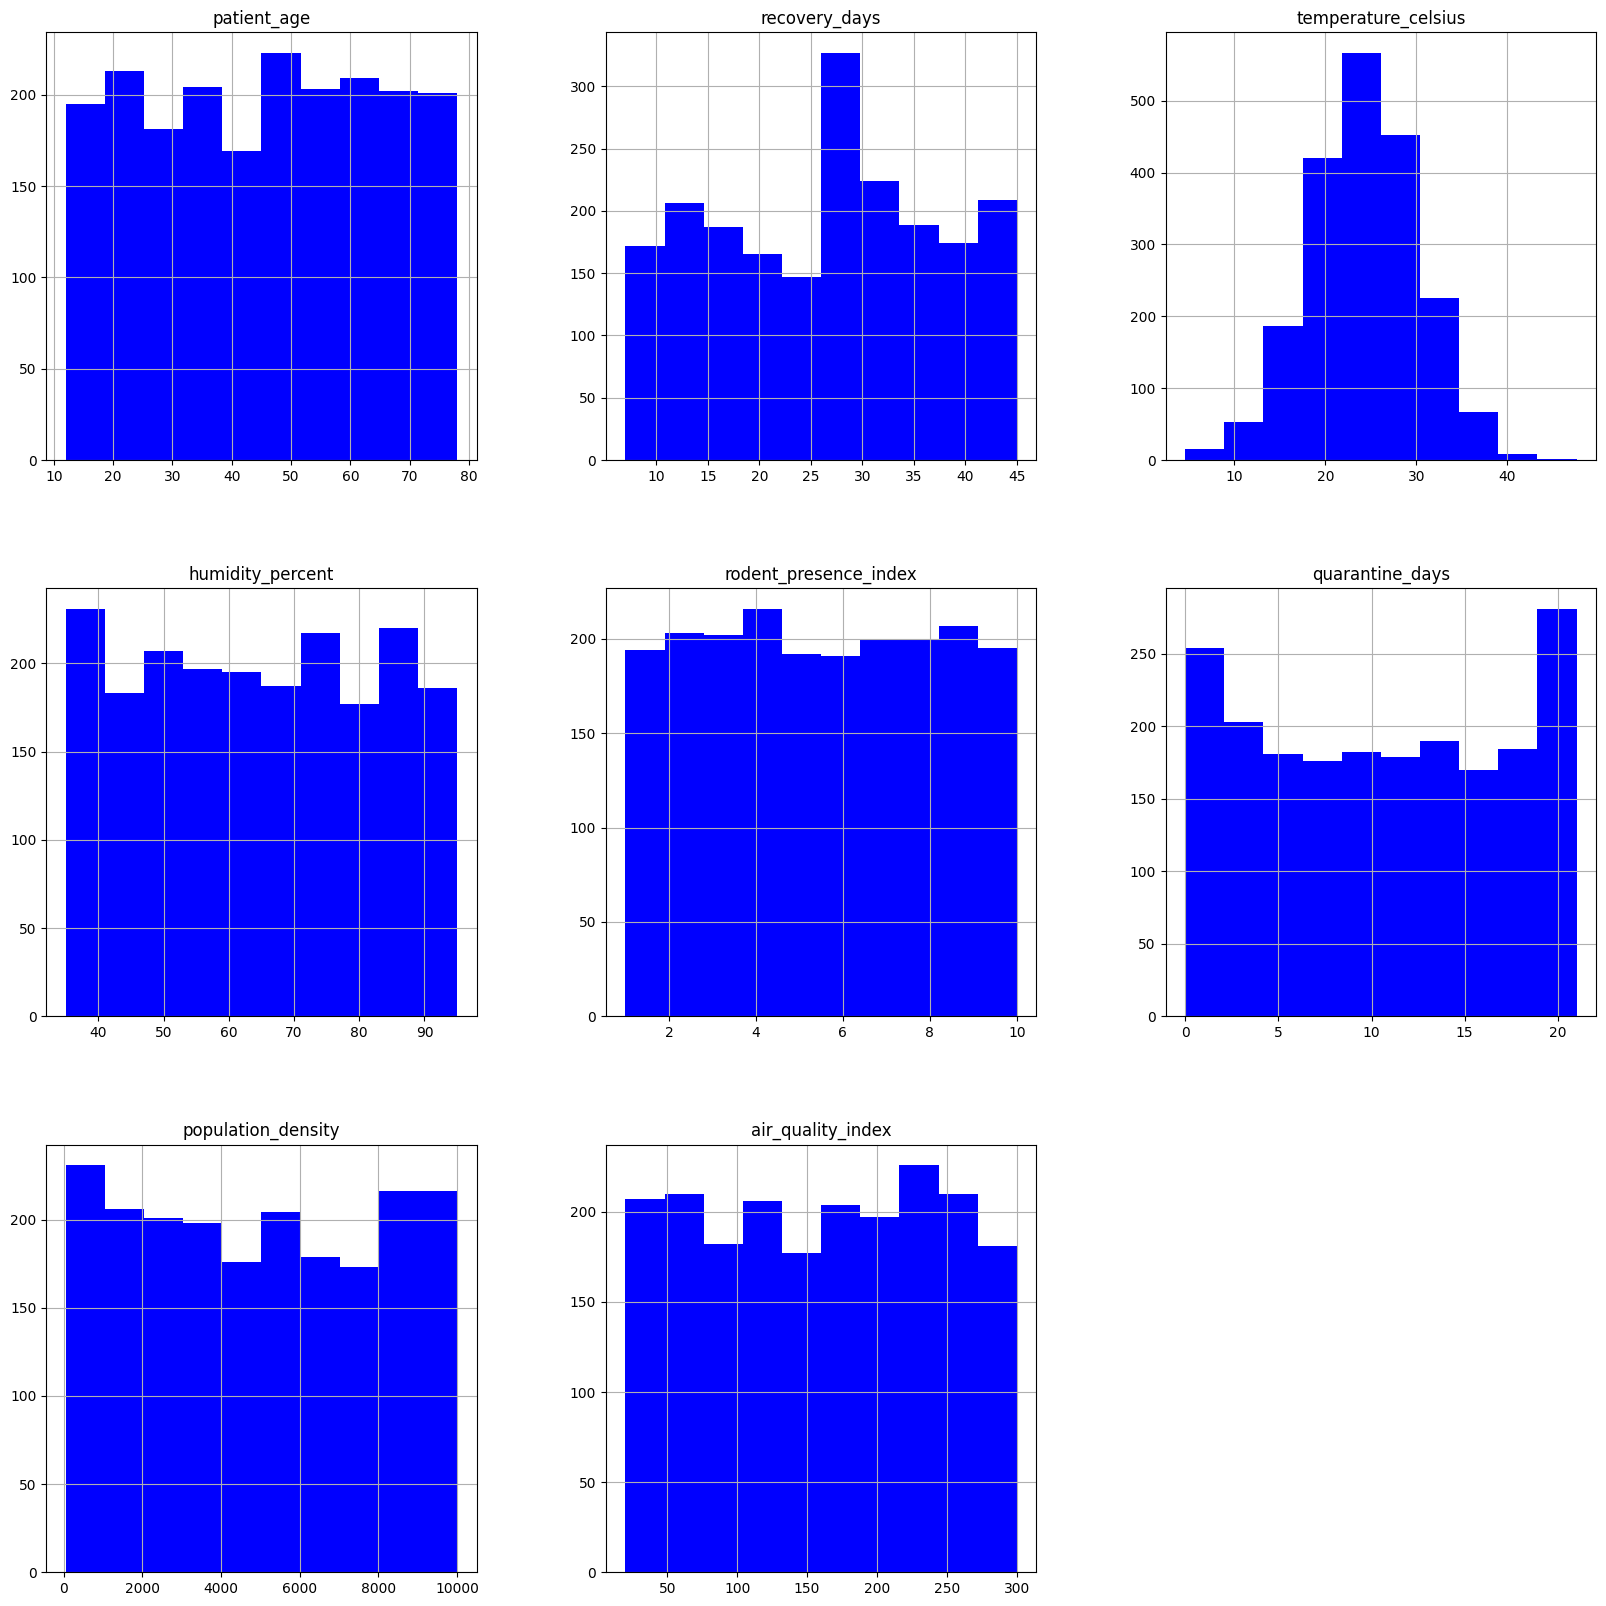

In [ ]:
# Histogram:
data1.hist(figsize=(20,20), color='blue')
plt.show()

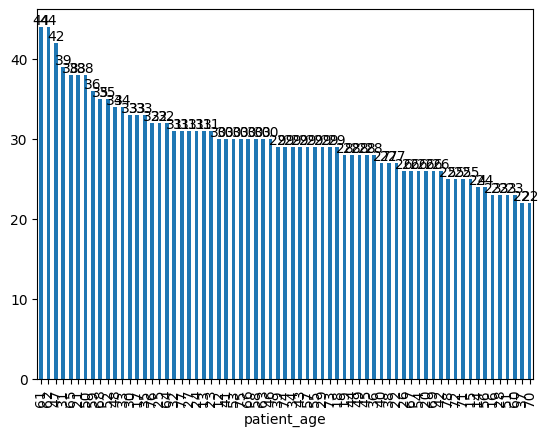

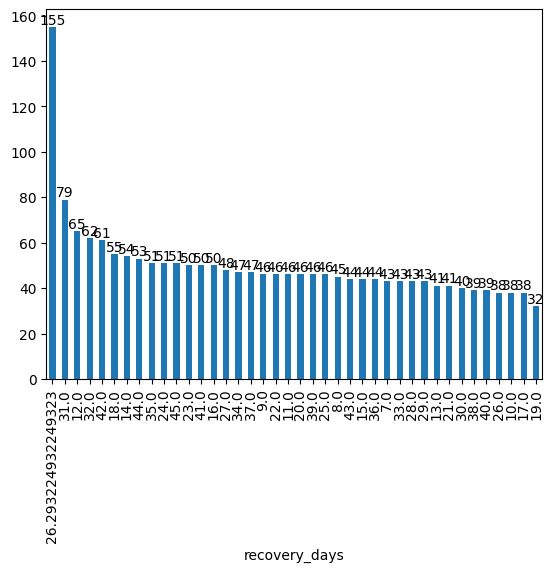

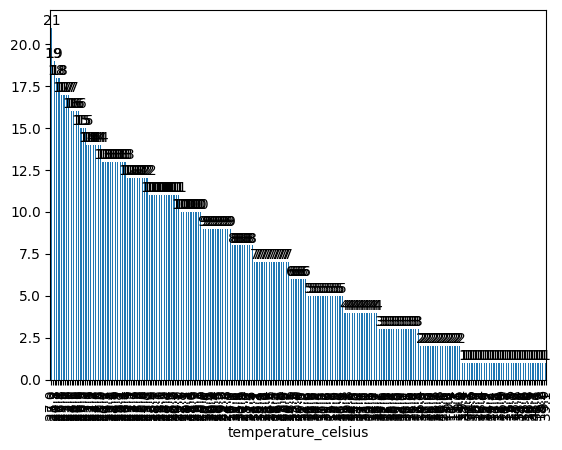

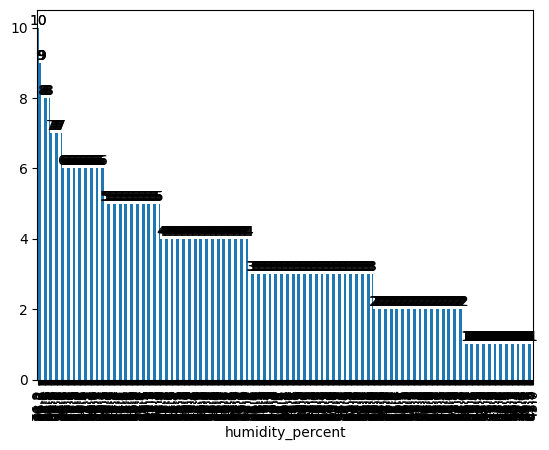

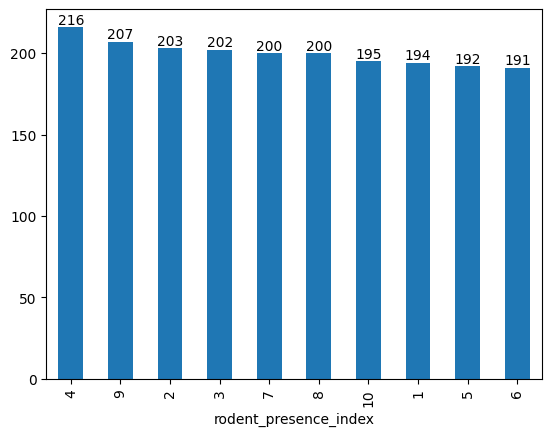

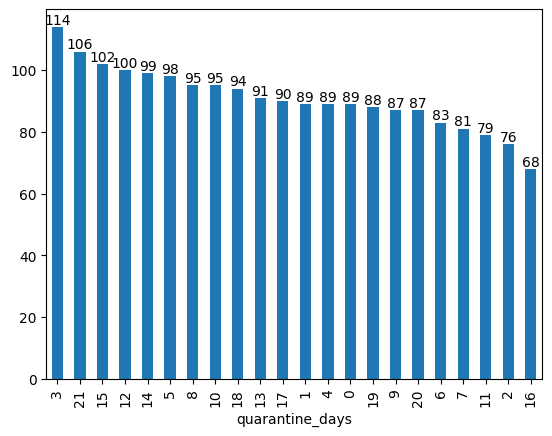

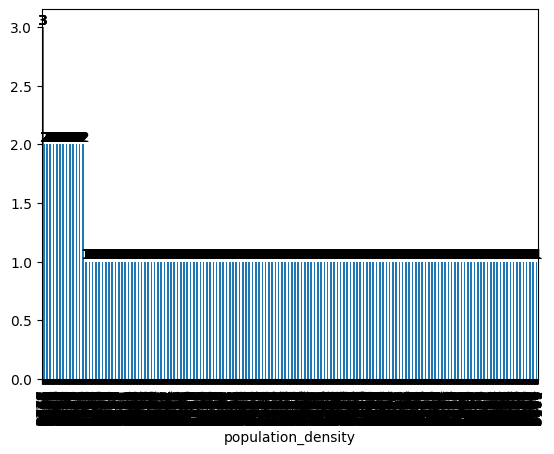

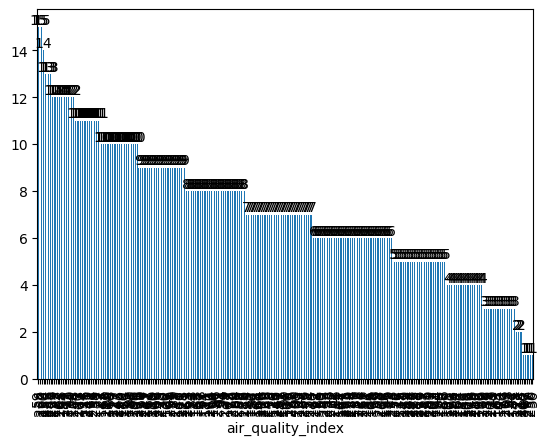

In [ ]:
# Bar Chart
for col in Numerical_columns:
    ax = data1[col].value_counts().plot(kind = 'bar')
    for i in ax.containers:
        ax.bar_label(i)
    plt.show()

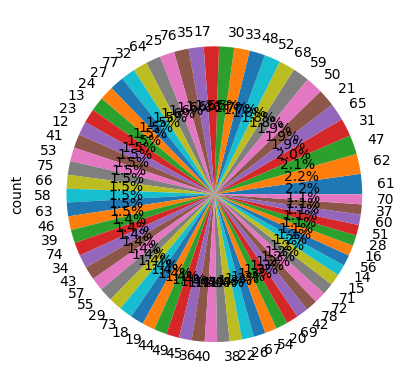

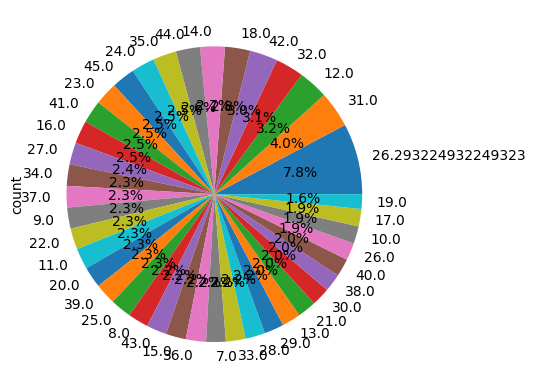

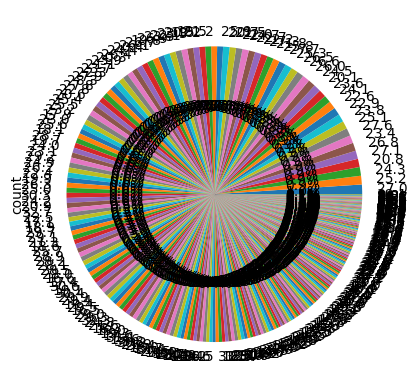

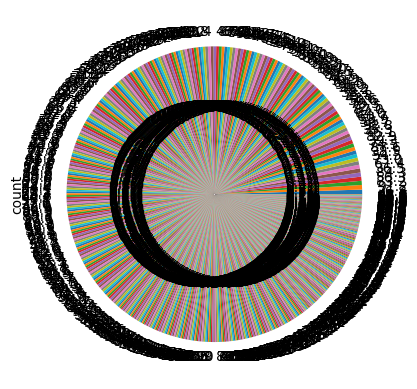

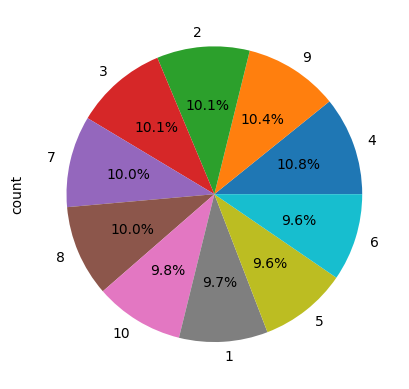

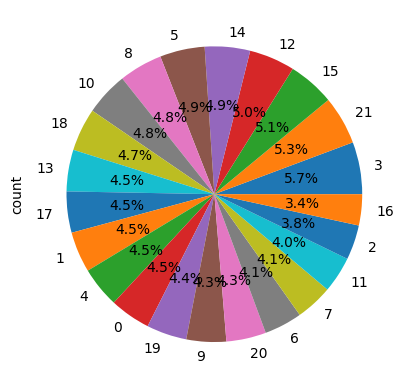

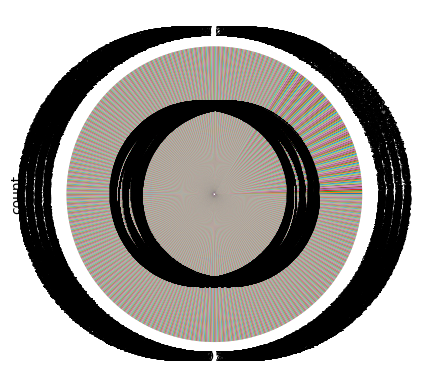

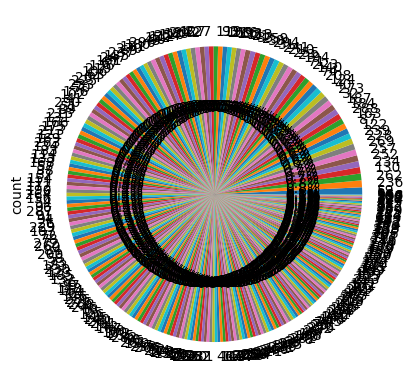

In [ ]:
# Pie Plot

for col in Numerical_columns:
  data1[col].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
  plt.show()

In [ ]:
#pairplot
sns.pairplot(data1)
plt.show()

In [ ]:
corr_data = data1[['patient_age', 'quarantine_days', 'recovery_days']].corr()
corr_data

,patient_age,quarantine_days,recovery_days
patient_age,1.000000,-0.029849,-0.029793
quarantine_days,-0.029849,1.000000,-0.021276
recovery_days,-0.029793,-0.021276,1.000000


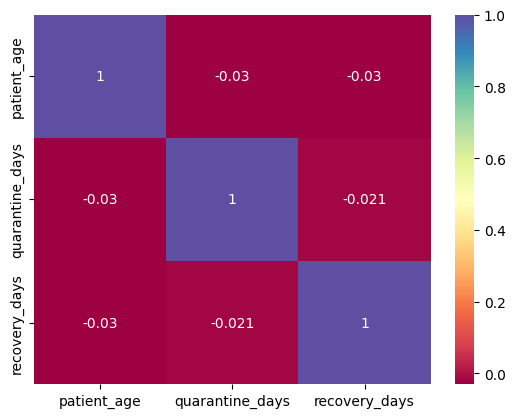

In [ ]:
sns.heatmap(corr_data, annot=True, cmap='Spectral')
plt.show()

In [ ]:
# Label encoding: where need to convert categorical data into numerical
# Data Pre-Processing

In [ ]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #if we initialise label encoder in one variable like le so we don't need to type lable encoder in every encoding only use le

In [ ]:
Categorical_columns = data1.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

['case_id', 'country', 'region', 'report_date', 'virus_strain', 'transmission_type', 'exposure_source', 'gender', 'symptoms', 'hospitalization', 'fatality']


In [ ]:
data1['case_id'] = le.fit_transform(data1['case_id'])
data1['country'] = le.fit_transform(data1['country'])
data1['region'] = le.fit_transform(data1['region'])
data1['report_date'] = le.fit_transform(data1['report_date'])
data1['virus_strain'] = le.fit_transform(data1['virus_strain'])
data1['transmission_type'] = le.fit_transform(data1['transmission_type'])
data1['exposure_source'] = le.fit_transform(data1['exposure_source'])
data1['gender'] = le.fit_transform(data1['gender'])
data1['symptoms'] = le.fit_transform(data1['symptoms'])
data1['hospitalization'] = le.fit_transform(data1['hospitalization'])
data1['fatality'] = le.fit_transform(data1['fatality'])

In [ ]:
data1

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index,Etransmission_type
0,0,3,718,390,4,1,0,26,1,3,1,0,22.0,27.0,78.9,7,1,538,67,1
1,1,1,271,350,4,0,3,41,0,2,1,0,41.0,23.2,70.9,3,13,5624,162,0
2,2,4,1387,332,3,0,3,39,0,2,0,0,31.0,22.6,38.5,8,17,2095,213,0
3,3,0,1781,152,4,0,4,49,1,2,0,0,11.0,22.6,87.0,7,8,7478,206,0
4,4,4,794,396,1,1,3,59,1,1,0,0,24.0,33.5,36.2,8,12,4472,132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,1,1523,183,0,1,3,43,0,4,0,0,30.0,25.9,71.6,2,2,9022,72,1
1996,1996,2,992,265,2,0,4,52,0,4,1,0,35.0,17.3,50.7,8,14,7014,67,0
1997,1997,5,197,310,1,0,5,64,0,3,0,0,24.0,23.8,60.1,3,19,309,210,0
1998,1998,6,1670,489,3,1,3,29,1,4,0,0,45.0,26.1,52.3,3,7,3843,21,1


In [ ]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data1.columns

Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index',
       'Etransmission_type'],
      dtype='object')

In [ ]:
# Define features (X) and target (y)
X = data1[['patient_age',
        'recovery_days',
        'temperature_celsius',
        'humidity_percent',
        'rodent_presence_index',
        'quarantine_days']]
y = data1["air_quality_index"]

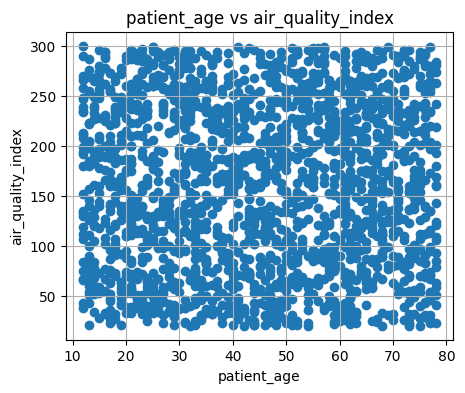

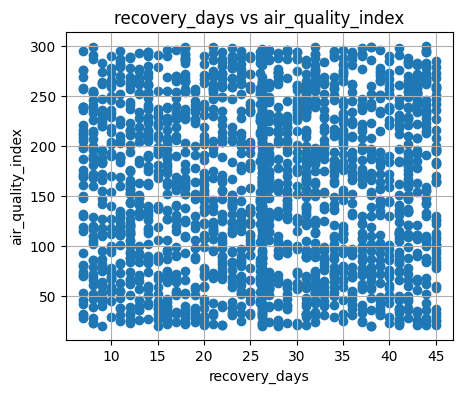

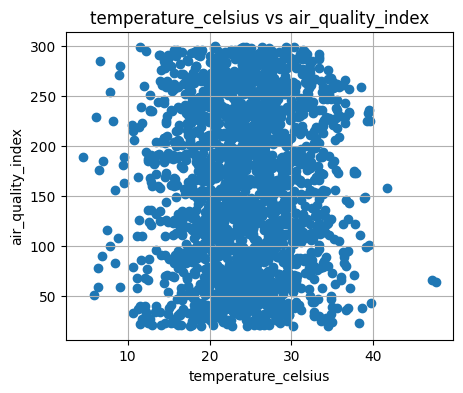

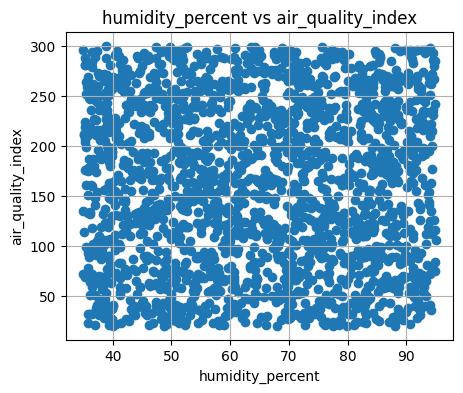

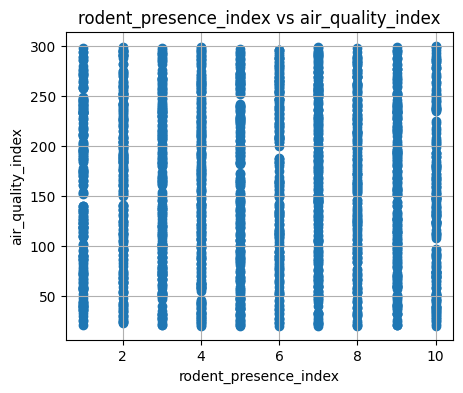

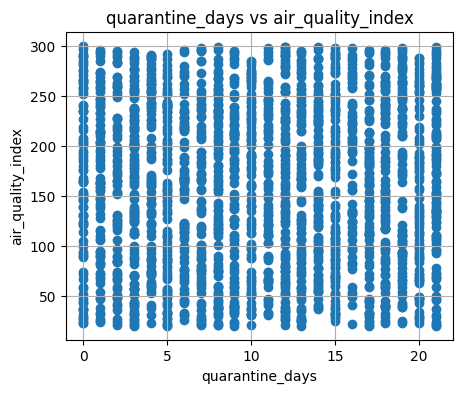

In [ ]:
X = data1[['patient_age',
           'recovery_days',
           'temperature_celsius',
           'humidity_percent',
           'rodent_presence_index',
           'quarantine_days']]


y = data1['air_quality_index']

# Create scatter plots
for column in X.columns:
    plt.figure(figsize=(5,4))
    plt.scatter(X[column], y)
    plt.xlabel(column)
    plt.ylabel('air_quality_index')
    plt.title(f'{column} vs air_quality_index')
    plt.grid(True)
    plt.show()

In [ ]:
#  Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)


Training Set Size: (1600, 6)
Testing Set Size: (400, 6)


In [ ]:
#  Model Training
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [ ]:
# Step 6: Model Coefficients "General linear equation: Y=β0+β1X1+β2X2+β3X3+...+βnXn+ε "
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:", model.intercept_)


Model Coefficients:
                       Coefficient
patient_age               0.007896
recovery_days             0.123834
temperature_celsius       0.082461
humidity_percent         -0.000101
rodent_presence_index    -1.112925
quarantine_days           0.005543
Intercept: 160.94643382546124


In [ ]:
# Step : 7 Predictions
y_pred = model.predict(X_test)

In [ ]:
# Step 8: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.3f}")



Model Performance:
Mean Absolute Error (MAE): 70.84
Mean Squared Error (MSE): 6647.27
R² Score: -0.006


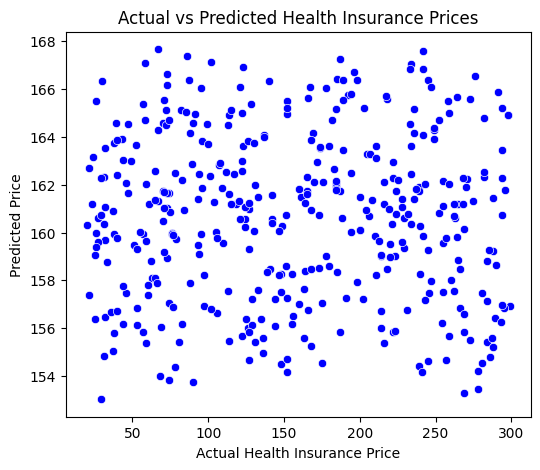

In [ ]:
# Step 9: Visualization

# Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, color="blue")
plt.xlabel("Actual Health Insurance Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Health Insurance Prices")
# Save the graph
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

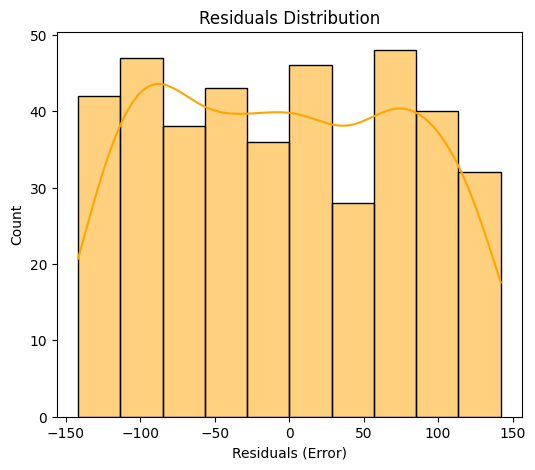

In [ ]:
# Residual Plot
plt.figure(figsize=(6, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

# Save the plot
plt.savefig("residuals_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

Conclusion

The Linear Regression model was developed to understand the relationship between environmental and patient-related factors and to predict continuous values in a healthcare context. The variables
are  patient age, recovery days, temperature, humidity, rodent presence index, and quarantine days.

The model performance showed a Mean Absolute Error (MAE) of 70.84 and Mean Squared Error (MSE) of 6647.27, indicating a  difference between actual and predicted values.

The regression coefficients of each variable:
                       Coefficient
patient_age               0.007896
recovery_days             0.123834
temperature_celsius       0.082461
humidity_percent         -0.000101
rodent_presence_index    -1.112925
quarantine_days           0.005543

In the above list we can see all coefficents of all variables,in this rodent_presence_index has the largest impact because it has the highest coefficient magnitude (-1.112925).

